# 07b · Eşlenik Priorlar (Conjugate Priors)
**Probability Lab** · Bayes Module

---
> **Bu notebook'ta ne öğreneceğiz?**  
> Önceki notebook'ta (`bayes_theorem.ipynb`) Beta-Binomial güncellemesini **kullandık** ama
> *neden* bu kadar kolay çalıştığını (integral almadan, sadece toplama ile posterior'u
> bulabildiğimizi) ispatlamadık. Bu notebook'ta o boşluğu dolduruyoruz — hem Beta-Binomial'in
> matematiksel ispatını hem de eşlenik prior ailesinin diğer üç önemli üyesini
> (Gamma-Poisson, Normal-Normal, Dirichlet-Multinomial) işleyeceğiz.

**Önkoşul:** Bayes Teoremi (07a), Beta/Gamma/Normal Dağılımlar (03), Poisson Dağılımı (02)  
**Veri:**  
- `cookie_cats.csv` — Mobil oyun verisi (`sum_gamerounds` — Gamma-Poisson için sayım verisi)  
- `ab_data.csv` — Web sitesi A/B testi (Beta-Binomial için, 07a'dan devam)  
- `creditcard.csv` — Kredi kartı işlemleri (`Amount` — Normal-Normal için sürekli veri)  
**Araçlar:** Python (numpy, scipy), R (ggplot2), SQL (DuckDB)

---
## 1 · Eşlenik Prior (Conjugate Prior) Nedir?

**Tanım:** Bir prior dağılım, eğer posterior dağılım da **aynı dağılım ailesinden** çıkıyorsa,
o prior likelihood fonksiyonuna göre "eşleniktir" (conjugate) denir.

Somut olarak: Beta dağılımlı bir prior'a Binomial likelihood uygularsan, posterior yine bir
Beta dağılımı çıkar (sadece parametreleri değişir). Bu "aynı aile içinde kalma" özelliği,
07a'da gördüğümüz gibi posterior'u **karmaşık bir integral almadan, sadece iki sayı toplayarak**
bulmamızı sağlıyor.

---
## 2 · Neden Önemli? (Hesaplama Verimliliği)

Bayes formülünün paydası ($P(B)$ = Evidence) genel olarak şu integrali gerektirir:
$$P(B) = \int P(B \mid \theta) P(\theta) \, d\theta$$

Çoğu dağılım kombinasyonunda bu integralin **kapalı-form (analitik) bir çözümü yoktur** —
sayısal yöntemlerle (MCMC, varyasyonel çıkarım gibi) yaklaşık olarak hesaplaman gerekir, bu da
hem yavaş hem de hesaplama açısından pahalıdır.

Eşlenik prior kullanırsan, bu integrali **hiç hesaplamana gerek kalmaz** — posterior'un hangi
aileden olduğunu zaten bildiğin için, sadece parametrelerini güncellemen yeterli. Bu, özellikle
büyük veri ve gerçek-zamanlı sistemlerde (örn. reklam gösterimi optimizasyonu, ki bu bir
Bayesyen A/B testi senaryosudur) kritik bir performans avantajı sağlar.

---
## 3 · Beta-Binomial Eşlenikliğinin İspatı

**Prior:** $\theta \sim \text{Beta}(\alpha, \beta)$, yani $P(\theta) \propto \theta^{\alpha-1}(1-\theta)^{\beta-1}$

**Likelihood:** $n$ denemede $k$ başarı gözlemlersek (Binomial), $P(D\mid\theta) \propto \theta^k(1-\theta)^{n-k}$
(Binomial katsayısı $\theta$'ya bağlı olmadığı için orantı işaretinde göz ardı edilebilir)

**Bayes ile posterior:**
$$P(\theta \mid D) \propto P(D\mid\theta) \cdot P(\theta) \propto \theta^k(1-\theta)^{n-k} \cdot \theta^{\alpha-1}(1-\theta)^{\beta-1}$$

Üsleri topla (aynı tabanlı terimler çarpılınca üsler toplanır):
$$P(\theta \mid D) \propto \theta^{(\alpha+k)-1}(1-\theta)^{(\beta+n-k)-1}$$

Bu ifade **tam olarak** bir $\text{Beta}(\alpha+k, \beta+n-k)$ dağılımının çekirdeği (normalize
edilmemiş hali)! Yani posterior da bir Beta dağılımı — ispat tamamlandı. Aşağıda bunu sayısal
olarak da doğrulayacağız: elle çarpıp normalize ettiğimiz eğri ile analitik formülün eğrisi
birebir çakışacak.

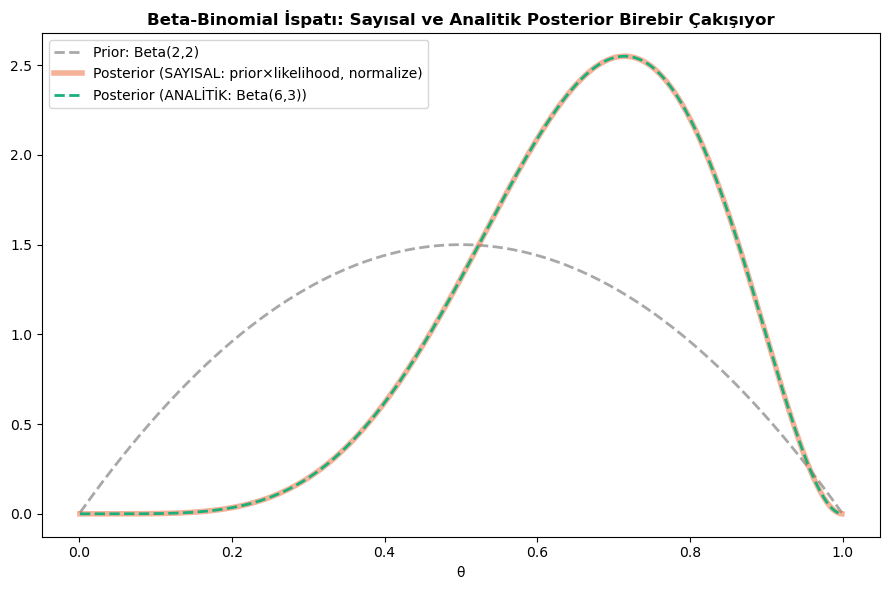

İki eğri arasındaki maksimum fark: 0.000000 (pratikte sıfır - sayısal hassasiyet dışında)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Basit bir sayısal ornek: prior Beta(2,2), 5 denemede 4 basari gozlemledik
alpha_prior, beta_prior = 2, 2
n, k = 5, 4

theta_grid = np.linspace(0.001, 0.999, 500)

# 1) ELLE: prior x likelihood, sonra sayisal olarak normalize et (integral yerine toplam)
prior_vals = stats.beta.pdf(theta_grid, alpha_prior, beta_prior)
likelihood_vals = (theta_grid ** k) * ((1 - theta_grid) ** (n - k))  # Binomial katsayisiz
unnormalized_posterior = prior_vals * likelihood_vals
dtheta = theta_grid[1] - theta_grid[0]
normalized_posterior_numeric = unnormalized_posterior / (unnormalized_posterior.sum() * dtheta)  # Riemann toplami ile integral yaklasimi (np.trapz surum-bagimli, kacinildi)

# 2) ANALITIK: Beta(alpha+k, beta+n-k) formulunden dogrudan
alpha_post, beta_post = alpha_prior + k, beta_prior + (n - k)
posterior_analytic = stats.beta.pdf(theta_grid, alpha_post, beta_post)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(theta_grid, prior_vals, '--', color='#a8a8a8', linewidth=2, label=f'Prior: Beta({alpha_prior},{beta_prior})')
ax.plot(theta_grid, normalized_posterior_numeric, color='#eb6834', linewidth=4, alpha=0.5,
        label='Posterior (SAYISAL: prior×likelihood, normalize)')
ax.plot(theta_grid, posterior_analytic, '--', color='#1baf7a', linewidth=2,
        label=f'Posterior (ANALİTİK: Beta({alpha_post},{beta_post}))')
ax.set_title('Beta-Binomial İspatı: Sayısal ve Analitik Posterior Birebir Çakışıyor', fontweight='bold')
ax.set_xlabel('θ')
ax.legend()
plt.tight_layout()
plt.show()

fark = np.max(np.abs(normalized_posterior_numeric - posterior_analytic))
print(f"İki eğri arasındaki maksimum fark: {fark:.6f} (pratikte sıfır - sayısal hassasiyet dışında)")

---
## 4 · Gamma-Poisson Eşlenikliği

**Senaryo:** Poisson dağılımı bir **oranı** ($\lambda$) modelliyordu (birim zamanda kaç olay).
Bu oranın kendisi hakkında belirsizliğimiz varsa, onu bir dağılımla temsil etmemiz gerekir —
işte burada **Gamma dağılımı** devreye giriyor.

**Prior:** $\lambda \sim \text{Gamma}(\alpha, \beta)$ (şekil $\alpha$, oran/rate $\beta$)

**Likelihood:** $n$ gözlemde toplam $S = \sum x_i$ olay sayıldıysa (her $x_i \sim \text{Poisson}(\lambda)$)

**Posterior (ispat benzer şekilde üs toplama ile yapılır):**
$$\lambda \mid D \sim \text{Gamma}(\alpha + S, \ \beta + n)$$

Yorumu: $\alpha$'ya toplam gözlemlenen olay sayısını ($S$) ekliyorsun, $\beta$'ya gözlem
sayısını ($n$) ekliyorsun. Notlarındaki Gamma dağılımının "$\alpha$ tane olayın gerçekleşme
süresini modellemesi" yorumuyla birebir tutarlı.

---
## 5 · Normal-Normal Eşlenikliği

**Senaryo:** Bir popülasyonun ortalamasını ($\mu$) tahmin etmek istiyoruz, varyansın ($\sigma^2$)
bilindiğini varsayıyoruz (basitleştirme için).

**Prior:** $\mu \sim N(\mu_0, \tau_0^2)$

**Likelihood:** $X_i \sim N(\mu, \sigma^2)$, $n$ gözlem, örneklem ortalaması $\bar{x}$

**Posterior:**
$$\mu \mid D \sim N(\mu_n, \tau_n^2), \quad \text{burada} \quad \frac{1}{\tau_n^2} = \frac{1}{\tau_0^2} + \frac{n}{\sigma^2}, \quad \mu_n = \tau_n^2\left(\frac{\mu_0}{\tau_0^2} + \frac{n\bar{x}}{\sigma^2}\right)$$

Bu formül karmaşık görünüyor ama sezgisi basit: posterior ortalaması ($\mu_n$), prior
ortalaması ($\mu_0$) ile veri ortalaması ($\bar{x}$)'nin **ağırlıklı ortalaması** — ağırlıklar
her birinin "kesinliğine" (varyansın tersi, "precision") göre belirleniyor. Veri çoksa
($n$ büyükse) veya veri kesinse ($\sigma^2$ küçükse), posterior veriye daha çok kayar; prior
kesinse ($\tau_0^2$ küçükse), posterior prior'a daha çok yakın kalır.

---
## 6 · Dirichlet-Multinomial Eşlenikliği (Beta-Binomial'in Genellemesi)

Beta-Binomial sadece **iki kategori** (başarı/başarısızlık) için çalışıyordu. Kategori sayısı
ikiden fazlaysa (örn. bir ürünün "kötü / orta / iyi" olarak 3 kategoride değerlendirilmesi),
genellemesi gerekir:

**Prior:** $\mathbf{p} = (p_1,\dots,p_k) \sim \text{Dirichlet}(\alpha_1,\dots,\alpha_k)$

**Likelihood:** Multinomial — her kategoriden $n_1,\dots,n_k$ gözlem sayıldı

**Posterior:**
$$\mathbf{p} \mid D \sim \text{Dirichlet}(\alpha_1+n_1,\ \dots,\ \alpha_k+n_k)$$

Aynı mantık: her kategorinin gözlemlenen sayısını, o kategorinin prior parametresine ekliyorsun.
Beta-Binomial'in $k=2$ özel hali olduğunu görebilirsin — $\alpha_1=\alpha$, $\alpha_2=\beta$ dersen
birebir aynı formüle iner.

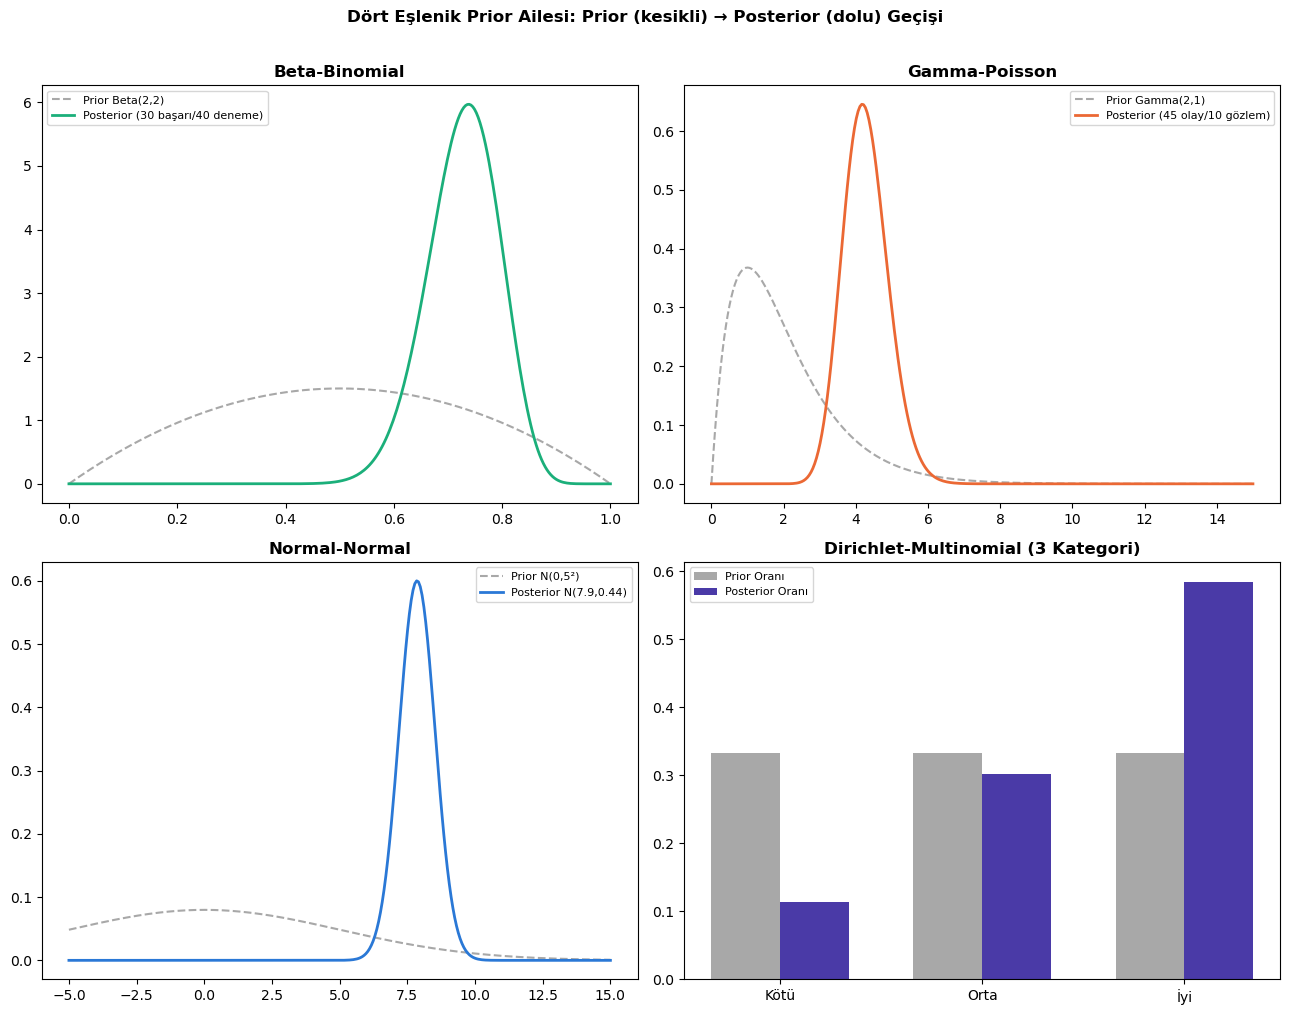

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# --- Panel 1: Beta-Binomial ---
ax = axes[0, 0]
x_beta = np.linspace(0, 1, 300)
ax.plot(x_beta, stats.beta.pdf(x_beta, 2, 2), '--', color='#a8a8a8', label='Prior Beta(2,2)')
ax.plot(x_beta, stats.beta.pdf(x_beta, 2+30, 2+10), color='#1baf7a', linewidth=2, label='Posterior (30 başarı/40 deneme)')
ax.set_title('Beta-Binomial', fontweight='bold')
ax.legend(fontsize=8)

# --- Panel 2: Gamma-Poisson ---
ax = axes[0, 1]
x_gamma = np.linspace(0, 15, 300)
ax.plot(x_gamma, stats.gamma.pdf(x_gamma, a=2, scale=1/1), '--', color='#a8a8a8', label='Prior Gamma(2,1)')
ax.plot(x_gamma, stats.gamma.pdf(x_gamma, a=2+45, scale=1/(1+10)), color='#eb6834', linewidth=2, label='Posterior (45 olay/10 gözlem)')
ax.set_title('Gamma-Poisson', fontweight='bold')
ax.legend(fontsize=8)

# --- Panel 3: Normal-Normal ---
ax = axes[1, 0]
x_norm = np.linspace(-5, 15, 300)
mu0, tau0 = 0, 5
sigma, n_obs, xbar = 3, 20, 8
tau_n2 = 1 / (1/tau0**2 + n_obs/sigma**2)
mu_n = tau_n2 * (mu0/tau0**2 + n_obs*xbar/sigma**2)
ax.plot(x_norm, stats.norm.pdf(x_norm, mu0, tau0), '--', color='#a8a8a8', label=f'Prior N({mu0},{tau0}²)')
ax.plot(x_norm, stats.norm.pdf(x_norm, mu_n, np.sqrt(tau_n2)), color='#2a78d6', linewidth=2,
        label=f'Posterior N({mu_n:.1f},{tau_n2:.2f})')
ax.set_title('Normal-Normal', fontweight='bold')
ax.legend(fontsize=8)

# --- Panel 4: Dirichlet-Multinomial (bar chart ile - 3 kategori) ---
ax = axes[1, 1]
kategoriler = ['Kötü', 'Orta', 'İyi']
prior_alpha = np.array([1, 1, 1])
gozlem = np.array([5, 15, 30])  # kotu/orta/iyi gozlem sayilari
posterior_alpha = prior_alpha + gozlem
prior_oran = prior_alpha / prior_alpha.sum()
posterior_oran = posterior_alpha / posterior_alpha.sum()

xpos = np.arange(3)
ax.bar(xpos - 0.17, prior_oran, width=0.34, color='#a8a8a8', label='Prior Oranı')
ax.bar(xpos + 0.17, posterior_oran, width=0.34, color='#4a3aa7', label='Posterior Oranı')
ax.set_xticks(xpos); ax.set_xticklabels(kategoriler)
ax.set_title('Dirichlet-Multinomial (3 Kategori)', fontweight='bold')
ax.legend(fontsize=8)

plt.suptitle('Dört Eşlenik Prior Ailesi: Prior (kesikli) → Posterior (dolu) Geçişi', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 7 · Eşlenik Prior Ailesi — Özet Tablo

| Likelihood | Eşlenik Prior | Posterior Güncelleme Kuralı |
|---|---|---|
| Bernoulli / Binomial | Beta $(\alpha,\beta)$ | Beta $(\alpha+k,\ \beta+n-k)$ |
| Poisson | Gamma $(\alpha,\beta)$ | Gamma $(\alpha+S,\ \beta+n)$ |
| Normal (bilinen $\sigma^2$) | Normal $(\mu_0,\tau_0^2)$ | Normal $(\mu_n,\tau_n^2)$ (yukarıdaki formül) |
| Multinomial | Dirichlet $(\alpha_1,\dots,\alpha_k)$ | Dirichlet $(\alpha_1+n_1,\dots,\alpha_k+n_k)$ |
| Exponential | Gamma $(\alpha,\beta)$ | Gamma $(\alpha+n,\ \beta+S)$ |

---
## 8 · Sınırlamalar: Her Zaman Eşlenik Prior Bulunmaz

Gerçek dünyada modelin karmaşıklığı arttıkça (örn. derin öğrenme modellerinin parametreleri,
hiyerarşik modeller), likelihood fonksiyonuna uyan bir eşlenik prior **bulunamayabilir**. Bu
durumlarda posterior'u analitik olarak hesaplayamazsın — bunun yerine:

- **MCMC (Markov Chain Monte Carlo):** Posterior'dan örnekleme yaparak yaklaşık dağılımı inşa etme
- **Varyasyonel Çıkarım (Variational Inference):** Posterior'u daha basit bir dağılımla yaklaşıklama

Bu iki yöntem, modern Bayesyen makine öğrenmesinin (örn. PyMC, Stan gibi kütüphanelerin) temelini
oluşturuyor — ama onlar için önce bu notebook'taki temel mantığı (prior × likelihood → posterior)
sağlam kavraman gerekiyor.

---
# 🐍 Python Uygulaması

5 adımda ilerleyeceğiz:
1. **Beta-Binomial (Gerçek Veri)** — İspatı gerçek A/B test verisiyle, prior/likelihood/posterior üçlüsünü aynı grafikte
2. **Gamma-Poisson** — Cookie Cats oyun turu verisinden oyuncu başına ortalama oyun oranını tahmin etme
3. **Normal-Normal** — Kredi kartı işlem tutarının ortalamasını, önsel bilgiyle güncelleme
4. **Dirichlet-Multinomial** — Çok kategorili bir memnuniyet dağılımını güncelleme
5. **Eşlenik Olmayan Prior Ne Olurdu?** — Kapalı-form çözümün olmadığı bir senaryoyu sayısal olarak (grid approximation) çözme

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Hazır ✓')

Hazır ✓


---
### 🅰️🅱️ Python 1 — Beta-Binomial: Prior, Likelihood, Posterior Üçlüsü

**Ne yapıyoruz?**  
07a'da sadece posterior'ları çizmiştik. Bu sefer **üçünü birden** (prior, likelihood'un
şekli, posterior) aynı grafikte göstererek, posterior'un aslında ikisinin "ortası" bir yerde
oluştuğunu görselleştireceğiz.

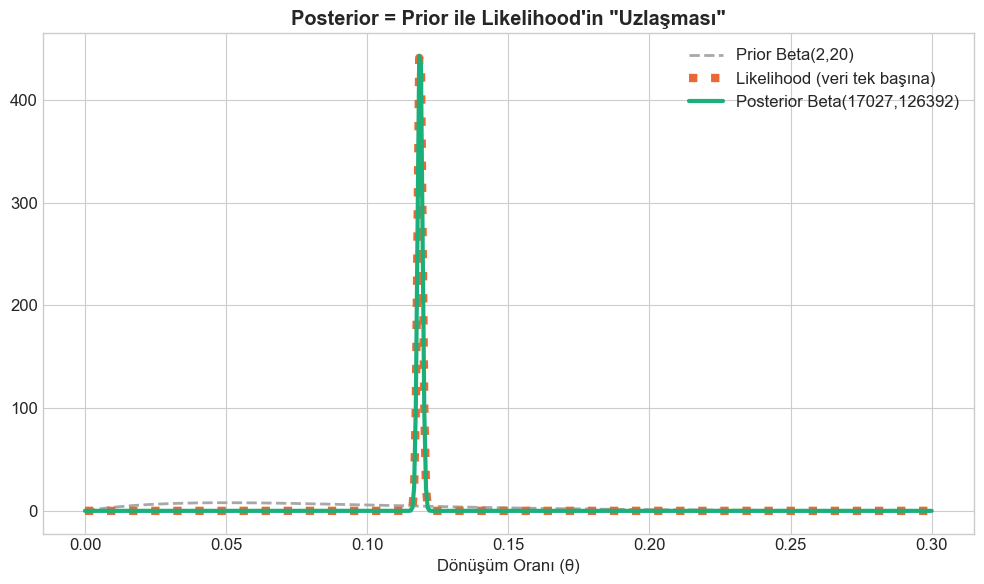

Prior ortalaması: 0.0909
Sadece veri (likelihood) ortalaması: 0.1187
Posterior ortalaması: 0.1187

YORUM: Posterior, prior ile verinin arasında bir yerde duruyor - veri ne kadar
çoksa (n büyükse), posterior o kadar veriye yaklaşır; prior ne kadar 'kesinse'
(alpha+beta büyükse), posterior o kadar prior'a yakın kalır.


In [5]:
ab = pd.read_csv('data/ab_data.csv')
tekrar_eden = ab['user_id'].value_counts()
gecerli_id = tekrar_eden[tekrar_eden == 1].index
ab_clean = ab[ab['user_id'].isin(gecerli_id)]

treatment = ab_clean[ab_clean['group'] == 'treatment']
t_success, t_total = treatment['converted'].sum(), len(treatment)

alpha_prior, beta_prior = 2, 20  # Bu sefer bilgili bir prior kullanalim: "donusum orani muhtemelen dusuk"
alpha_post = alpha_prior + t_success
beta_post = beta_prior + (t_total - t_success)

theta = np.linspace(0, 0.3, 500)
prior_curve = stats.beta.pdf(theta, alpha_prior, beta_prior)
# likelihood'u da bir Beta seklinde normalize ederek gosterelim (karsilastirma amacli)
likelihood_curve = stats.beta.pdf(theta, t_success + 1, (t_total - t_success) + 1)
posterior_curve = stats.beta.pdf(theta, alpha_post, beta_post)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(theta, prior_curve, '--', color='#a8a8a8', linewidth=2, label=f'Prior Beta({alpha_prior},{beta_prior})')
ax.plot(theta, likelihood_curve, ':', color='#eb6834', linewidth=6, label='Likelihood (veri tek başına)')
ax.plot(theta, posterior_curve, color='#1baf7a', linewidth=3, label=f'Posterior Beta({alpha_post},{beta_post})')
ax.set_title('Posterior = Prior ile Likelihood\'in "Uzlaşması"', fontweight='bold')
ax.set_xlabel('Dönüşüm Oranı (θ)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Prior ortalaması: {alpha_prior/(alpha_prior+beta_prior):.4f}")
print(f"Sadece veri (likelihood) ortalaması: {t_success/t_total:.4f}")
print(f"Posterior ortalaması: {alpha_post/(alpha_post+beta_post):.4f}")
print("\nYORUM: Posterior, prior ile verinin arasında bir yerde duruyor - veri ne kadar")
print("çoksa (n büyükse), posterior o kadar veriye yaklaşır; prior ne kadar 'kesinse'")
print("(alpha+beta büyükse), posterior o kadar prior'a yakın kalır.")

---
### 🎮 Python 2 — Gamma-Poisson: Oyuncu Başına Ortalama Oyun Turu Oranı

**Ne yapıyoruz?**  
`sum_gamerounds` (bir oyuncunun toplam oynadığı tur sayısı) bir **sayım verisi** — Poisson
modellemesi için uygun. Gamma prior ile "ortalama oyuncu ne kadar tur oynar" sorusuna
Bayesyen bir tahmin üreteceğiz.

N=89283, Ortalama tur sayısı: 44.49

Gamma-Poisson Posterior: Gamma(3972070, 89284)
Posterior ortalama oran tahmini (λ): 44.488
(Karşılaştırma - ham veri ortalaması: 44.488)


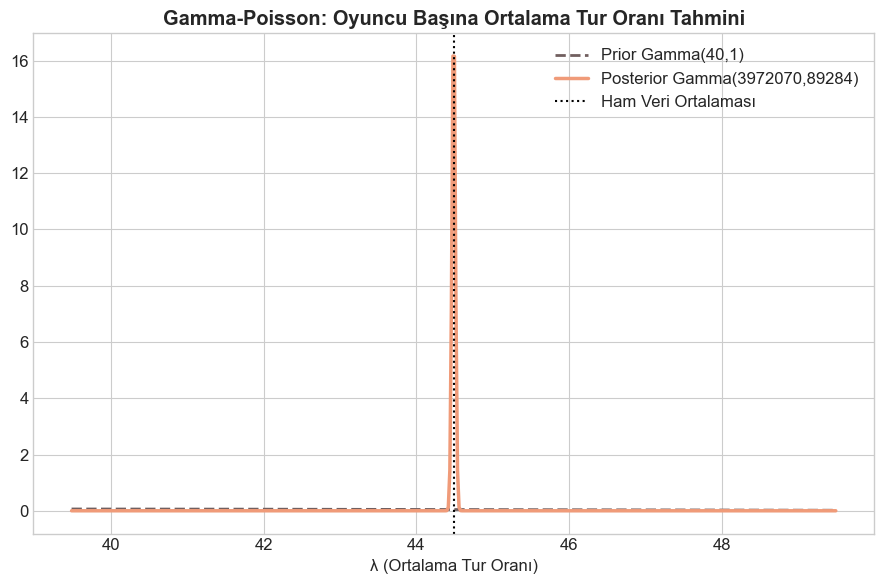


YORUM: n çok büyük olduğu için (binlerce oyuncu), prior'un etkisi neredeyse kayboldu -
posterior neredeyse tamamen ham veri ortalamasına eşit. Bu, 'çok veri varsa prior'un önemi azalır' kuralının gösterimi.


In [9]:
cookie = pd.read_csv('data/cookie_cats.csv')

# Asiri uc degerleri (bazi oyuncular binlerce tur oynamis olabilir) kirpalim, Poisson varsayimina daha uygun olsun
rounds = cookie['sum_gamerounds']
rounds_clean = rounds[rounds < rounds.quantile(0.99)]

print(f"N={len(rounds_clean)}, Ortalama tur sayısı: {rounds_clean.mean():.2f}")

# Prior: onceki oyunlardan biliyoruz ki ortalama oyuncu ~30-50 tur oynuyor -> Gamma(a=40, rate=1) gibi zayif bir prior
alpha_prior_g, beta_prior_g = 40, 1

n_oyuncu = len(rounds_clean)
toplam_tur = rounds_clean.sum()

alpha_post_g = alpha_prior_g + toplam_tur
beta_post_g = beta_prior_g + n_oyuncu

posterior_mean = alpha_post_g / beta_post_g
print(f"\nGamma-Poisson Posterior: Gamma({alpha_post_g:.0f}, {beta_post_g})")
print(f"Posterior ortalama oran tahmini (λ): {posterior_mean:.3f}")
print(f"(Karşılaştırma - ham veri ortalaması: {rounds_clean.mean():.3f})")

x = np.linspace(posterior_mean - 5, posterior_mean + 5, 500)
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(x, stats.gamma.pdf(x, a=alpha_prior_g, scale=1/beta_prior_g), '--', color="#715F5F", linewidth=2,
        label=f'Prior Gamma({alpha_prior_g},{beta_prior_g})')
ax.plot(x, stats.gamma.pdf(x, a=alpha_post_g, scale=1/beta_post_g), color="#f09b79", linewidth=2.5,
        label=f'Posterior Gamma({alpha_post_g:.0f},{beta_post_g})')
ax.axvline(rounds_clean.mean(), color='black', linestyle=':', label='Ham Veri Ortalaması')
ax.set_title('Gamma-Poisson: Oyuncu Başına Ortalama Tur Oranı Tahmini', fontweight='bold')
ax.set_xlabel('λ (Ortalama Tur Oranı)')
ax.legend()
plt.tight_layout()
plt.show()

print("\nYORUM: n çok büyük olduğu için (binlerce oyuncu), prior'un etkisi neredeyse kayboldu -")
print("posterior neredeyse tamamen ham veri ortalamasına eşit. Bu, 'çok veri varsa prior'un önemi azalır' kuralının gösterimi.")

---
### 💳 Python 3 — Normal-Normal: Kredi Kartı İşlem Tutarının Ortalamasını Tahmin Etme

**Ne yapıyoruz?**  
`Amount` sütununun gerçek ortalamasını, önceden "muhtemelen 80-90 dolar civarı" gibi kabaca
bir fikrimiz olduğunu varsayarak (prior), veriyle birlikte güncelleyeceğiz.

Prior: N(85, 15²)
Veri: n=281958, x̄=70.72, σ(bilinen)=129.04

Posterior: N(70.720, 0.0590)
Posterior standart sapması: 0.2430 (prior'unkinden 15, ÇOK daha dar!)


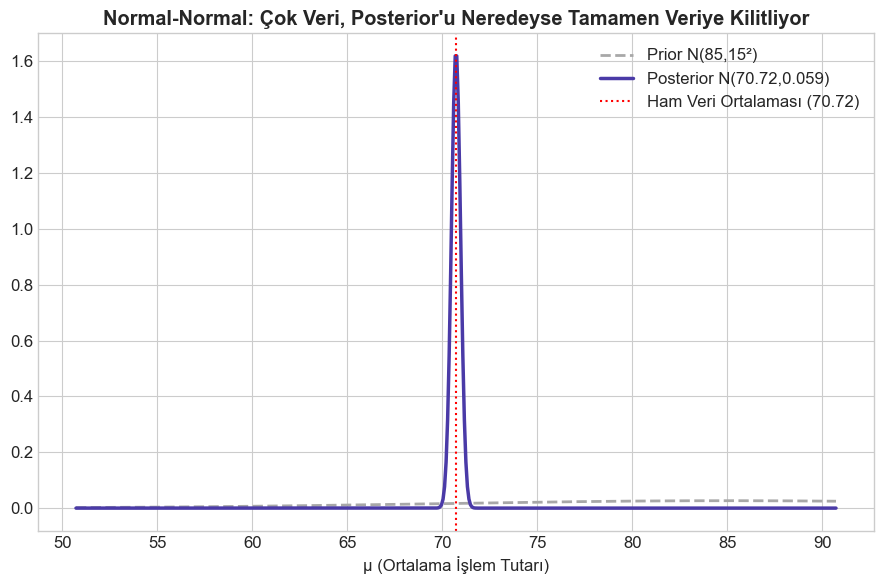

In [10]:
credit = pd.read_csv('data/creditcard.csv')
amount = credit['Amount']
amount_clean = amount[amount < amount.quantile(0.99)]  # asiri ucdegerleri kirp

sigma_bilinen = amount_clean.std()  # bilindigini varsaydigimiz populasyon std'si
n_obs = len(amount_clean)
x_bar = amount_clean.mean()

mu0, tau0 = 85, 15  # Prior: "ortalama muhtemelen 85 dolar civari, +-15 dolar belirsizlikle"

tau_n2 = 1 / (1/tau0**2 + n_obs/sigma_bilinen**2)
mu_n = tau_n2 * (mu0/tau0**2 + n_obs*x_bar/sigma_bilinen**2)

print(f"Prior: N({mu0}, {tau0}²)")
print(f"Veri: n={n_obs}, x̄={x_bar:.2f}, σ(bilinen)={sigma_bilinen:.2f}")
print(f"\nPosterior: N({mu_n:.3f}, {tau_n2:.4f})")
print(f"Posterior standart sapması: {np.sqrt(tau_n2):.4f} (prior'unkinden {tau0}, ÇOK daha dar!)")

x = np.linspace(mu_n - 20, mu_n + 20, 500)
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(x, stats.norm.pdf(x, mu0, tau0), '--', color='#a8a8a8', linewidth=2, label=f'Prior N({mu0},{tau0}²)')
ax.plot(x, stats.norm.pdf(x, mu_n, np.sqrt(tau_n2)), color='#4a3aa7', linewidth=2.5,
        label=f'Posterior N({mu_n:.2f},{tau_n2:.3f})')
ax.axvline(x_bar, color='red', linestyle=':', label=f'Ham Veri Ortalaması ({x_bar:.2f})')
ax.set_title('Normal-Normal: Çok Veri, Posterior\'u Neredeyse Tamamen Veriye Kilitliyor', fontweight='bold')
ax.set_xlabel('μ (Ortalama İşlem Tutarı)')
ax.legend()
plt.tight_layout()
plt.show()

---
### 🍽️ Python 4 — Dirichlet-Multinomial: Çok Kategorili Memnuniyet Anketi

**Ne yapıyoruz?**  
Gerçek bir sütun kullanmak yerine (bu veri setlerinde çok-kategorili bir sütun yok), sentetik
ama gerçekçi bir senaryo kuruyoruz: bir ürün yorumları "1-2 yıldız / 3 yıldız / 4-5 yıldız"
şeklinde 3 kategoriye ayrılıyor, Dirichlet-Multinomial ile kategori oranlarını güncelliyoruz.

Gözlemlenen yorum sayıları: {'1-2 Yıldız (Kötü)': np.int64(34), '3 Yıldız (Orta)': np.int64(55), '4-5 Yıldız (İyi)': np.int64(111)}
Prior Dirichlet([np.int64(2), np.int64(2), np.int64(2)])
Posterior Dirichlet([np.int64(36), np.int64(57), np.int64(113)])


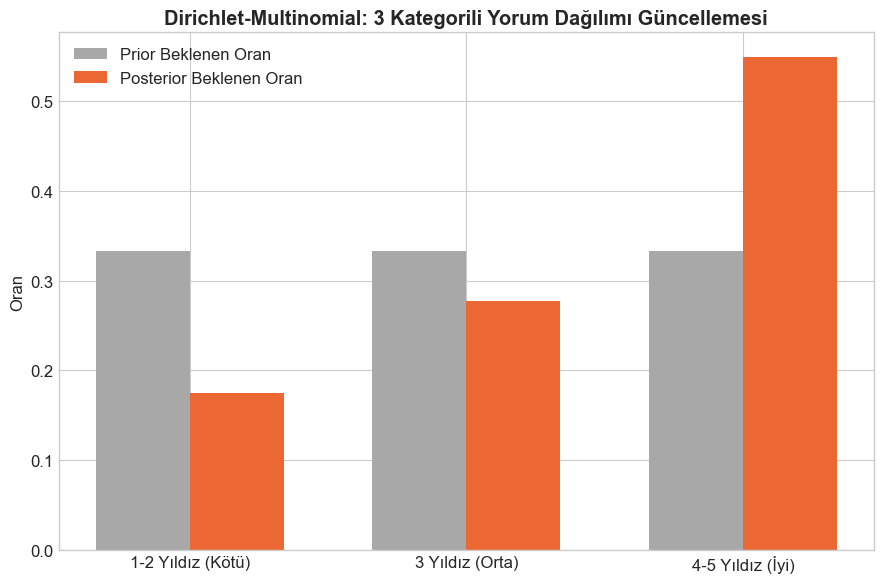

P(1-2 Yıldız (Kötü) en yüksek oranlı kategori) = 0.0000
P(3 Yıldız (Orta) en yüksek oranlı kategori) = 0.0000
P(4-5 Yıldız (İyi) en yüksek oranlı kategori) = 1.0000


In [11]:
kategoriler = ['1-2 Yıldız (Kötü)', '3 Yıldız (Orta)', '4-5 Yıldız (İyi)']

# Prior: gecmis urunlerden biliyoruz ki genelde dagilim yaklasik esit - zayif/belirsiz prior
prior_alpha = np.array([2, 2, 2])

# Yeni urun icin gozlemlenen yorumlar
rng = np.random.default_rng(5)
gercek_oranlar = [0.15, 0.25, 0.60]  # gizli "gercek" oranlar (simulasyon icin)
n_yorum = 200
gozlem = rng.multinomial(n_yorum, gercek_oranlar)

posterior_alpha = prior_alpha + gozlem

print("Gözlemlenen yorum sayıları:", dict(zip(kategoriler, gozlem)))
print(f"Prior Dirichlet({list(prior_alpha)})")
print(f"Posterior Dirichlet({list(posterior_alpha)})")

prior_beklenen = prior_alpha / prior_alpha.sum()
posterior_beklenen = posterior_alpha / posterior_alpha.sum()

fig, ax = plt.subplots(figsize=(9, 6))
xpos = np.arange(3)
ax.bar(xpos - 0.17, prior_beklenen, width=0.34, color='#a8a8a8', label='Prior Beklenen Oran')
ax.bar(xpos + 0.17, posterior_beklenen, width=0.34, color='#eb6834', label='Posterior Beklenen Oran')
ax.set_xticks(xpos); ax.set_xticklabels(kategoriler)
ax.set_ylabel('Oran')
ax.set_title('Dirichlet-Multinomial: 3 Kategorili Yorum Dağılımı Güncellemesi', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# Posterior'dan Monte Carlo ornekleme - hangi kategori en olasi lider?
samples = rng.dirichlet(posterior_alpha, size=50000)
en_yuksek_kategori = samples.argmax(axis=1)
for i, kat in enumerate(kategoriler):
    print(f"P({kat} en yüksek oranlı kategori) = {(en_yuksek_kategori == i).mean():.4f}")

---
### 🔬 Python 5 — Eşlenik Olmayan Bir Prior Seçseydik Ne Olurdu?

**Ne yapıyoruz?**  
Beta yerine, Binomial ile eşlenik OLMAYAN garip bir prior (örn. iki-tepeli/bimodal bir
dağılım) seçtiğimizi hayal edelim. Artık kapalı-form bir posterior formülümüz yok — bunun
yerine **grid approximation** (kaba kuvvet sayısal yöntem) kullanmak zorundayız. Bu, MCMC'nin
"neden var olduğunun" en basit örneği.

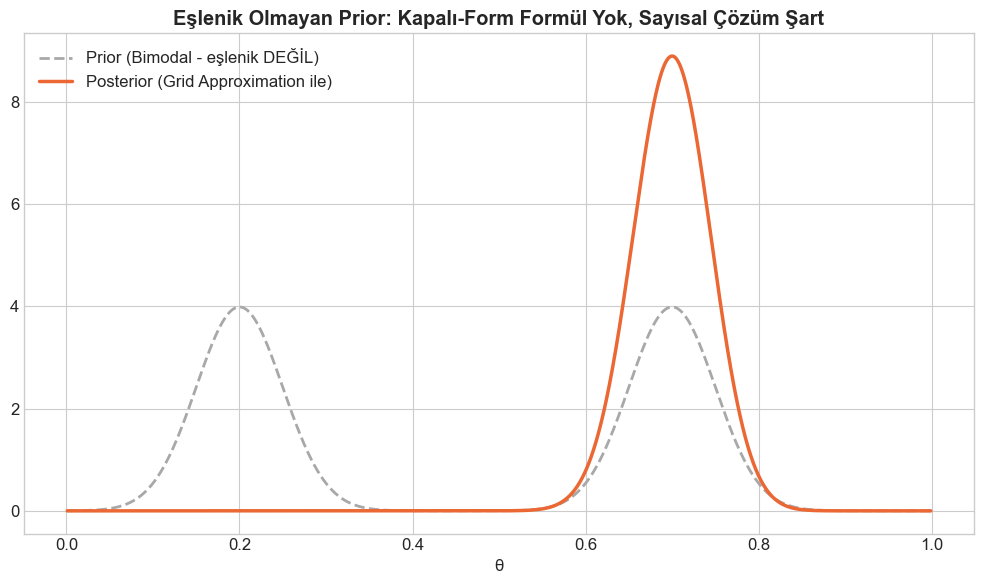

YORUM: Prior'un iki tepesi vardı (0.2 ve 0.7 civarı). Veri (14/20 başarı, yani %70 civarı)
geldiğinde, posterior 0.7 civarındaki tepeyi güçlendirip 0.2 civarındaki tepeyi bastırdı -
ama sonuç ARTIK BİR BETA DAĞILIMI DEĞİL, tuhaf/asimetrik bir şekil. Bunu formülle değil,
sadece grid üzerinde nokta nokta hesaplayarak (veya MCMC ile) bulabildik.


In [12]:
# Eslenik OLMAYAN prior: iki normal dagilimin karisimi (bimodal) - Beta ailesinden degil
theta_grid = np.linspace(0.001, 0.999, 2000)

def bimodal_prior(theta):
    return 0.5 * stats.norm.pdf(theta, 0.2, 0.05) + 0.5 * stats.norm.pdf(theta, 0.7, 0.05)

prior_vals = bimodal_prior(theta_grid)
prior_vals = prior_vals / (prior_vals.sum() * (theta_grid[1] - theta_grid[0]))  # normalize et

# Ayni Binomial likelihood (n=20 denemede k=14 basari)
n, k = 20, 14
likelihood_vals = (theta_grid ** k) * ((1 - theta_grid) ** (n - k))

unnormalized_posterior = prior_vals * likelihood_vals
dtheta = theta_grid[1] - theta_grid[0]
posterior_grid = unnormalized_posterior / (unnormalized_posterior.sum() * dtheta)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(theta_grid, prior_vals, '--', color='#a8a8a8', linewidth=2, label='Prior (Bimodal - eşlenik DEĞİL)')
ax.plot(theta_grid, posterior_grid, color='#eb6834', linewidth=2.5, label='Posterior (Grid Approximation ile)')
ax.set_title('Eşlenik Olmayan Prior: Kapalı-Form Formül Yok, Sayısal Çözüm Şart', fontweight='bold')
ax.set_xlabel('θ')
ax.legend()
plt.tight_layout()
plt.show()

print("YORUM: Prior'un iki tepesi vardı (0.2 ve 0.7 civarı). Veri (14/20 başarı, yani %70 civarı)")
print("geldiğinde, posterior 0.7 civarındaki tepeyi güçlendirip 0.2 civarındaki tepeyi bastırdı -")
print("ama sonuç ARTIK BİR BETA DAĞILIMI DEĞİL, tuhaf/asimetrik bir şekil. Bunu formülle değil,")
print("sadece grid üzerinde nokta nokta hesaplayarak (veya MCMC ile) bulabildik.")

---
# 📊 R Uygulaması

Python'da işlediğimiz üç ana eşlenik prior ailesini (Beta-Binomial, Gamma-Poisson, Normal-Normal)
R'da tekrarlıyoruz.

In [13]:
%load_ext rpy2.ipython

Error importing in API mode: ImportError("dlopen(/opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <2F94BB47-26EE-3EB3-85C5-1EA8A83C71AB> /opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


---
### 🅰️🅱️ R 1 — Beta-Binomial: Prior/Likelihood/Posterior Üçlüsü

**Yeni R kavramı yok** — `dbeta()` fonksiyonu ile üç eğriyi aynı grafikte çiziyoruz.

Prior: Beta( 2 , 20 )
Posterior: Beta( 17027 , 126392 )


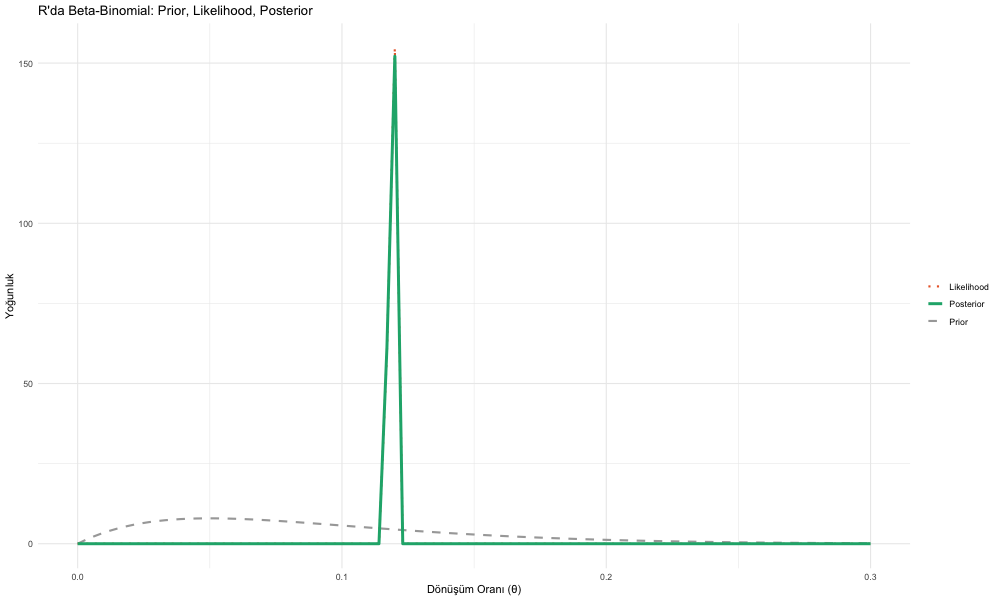

In [14]:
%%R -i ab_clean -w 1000 -h 600

library(ggplot2)

treatment_r <- ab_clean[ab_clean$group == "treatment", ]
t_success <- sum(treatment_r$converted); t_total <- nrow(treatment_r)

alpha_prior <- 2; beta_prior <- 20
alpha_post <- alpha_prior + t_success
beta_post <- beta_prior + (t_total - t_success)

cat("Prior: Beta(", alpha_prior, ",", beta_prior, ")\n")
cat("Posterior: Beta(", alpha_post, ",", beta_post, ")\n")

ggplot(data.frame(x = c(0, 0.3)), aes(x = x)) +
  stat_function(fun = dbeta, args = list(shape1 = alpha_prior, shape2 = beta_prior),
                aes(color = "Prior"), linetype = "dashed", linewidth = 1) +
  stat_function(fun = dbeta, args = list(shape1 = t_success + 1, shape2 = (t_total - t_success) + 1),
                aes(color = "Likelihood"), linetype = "dotted", linewidth = 1) +
  stat_function(fun = dbeta, args = list(shape1 = alpha_post, shape2 = beta_post),
                aes(color = "Posterior"), linewidth = 1.4) +
  scale_color_manual(values = c("Prior" = "#a8a8a8", "Likelihood" = "#eb6834", "Posterior" = "#1baf7a")) +
  labs(title = "R'da Beta-Binomial: Prior, Likelihood, Posterior",
       x = "Dönüşüm Oranı (θ)", y = "Yoğunluk", color = "") +
  theme_minimal()

---
### 🎮 R 2 — Gamma-Poisson: Oyun Turu Oranı Tahmini

**Yeni R kavramı:** `dgamma(x, shape=, rate=)` — Python'daki `stats.gamma.pdf(x, a=, scale=1/rate)`
çağrısının R karşılığı (R doğrudan `rate` parametresi alıyor, `scale` değil).

Posterior: Gamma( 3972070 , 89284 )
Posterior ortalama oran (lambda): 44.48804 


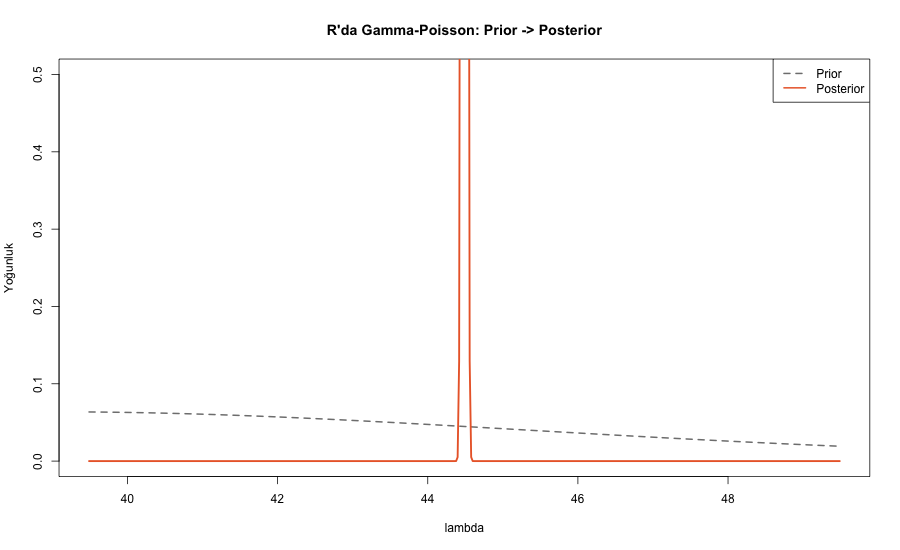

In [15]:
%%R -i cookie -w 900 -h 550

rounds_r <- cookie$sum_gamerounds
rounds_r <- rounds_r[rounds_r < quantile(rounds_r, 0.99)]

alpha_prior_g <- 40; beta_prior_g <- 1
n_oyuncu <- length(rounds_r)
toplam_tur <- sum(rounds_r)

alpha_post_g <- alpha_prior_g + toplam_tur
beta_post_g <- beta_prior_g + n_oyuncu

cat("Posterior: Gamma(", alpha_post_g, ",", beta_post_g, ")\n")
cat("Posterior ortalama oran (lambda):", alpha_post_g / beta_post_g, "\n")

x_vals <- seq(alpha_post_g/beta_post_g - 5, alpha_post_g/beta_post_g + 5, length.out = 500)
plot(x_vals, dgamma(x_vals, shape = alpha_prior_g, rate = beta_prior_g), type = "l", lty = 2,
     col = "gray50", lwd = 2, ylim = c(0, 0.5),
     main = "R'da Gamma-Poisson: Prior -> Posterior", xlab = "lambda", ylab = "Yoğunluk")
lines(x_vals, dgamma(x_vals, shape = alpha_post_g, rate = beta_post_g), col = "#eb6834", lwd = 2.5)
legend("topright", legend = c("Prior", "Posterior"), col = c("gray50", "#eb6834"), lty = c(2, 1), lwd = 2)

---
### 💳 R 3 — Normal-Normal: İşlem Tutarı Ortalaması

**Yeni R kavramı yok** — formülü doğrudan uyguluyoruz, Python'daki mantığın birebir tekrarı.

Posterior: N( 70.72 , 0.059 )
Posterior standart sapması: 0.243 


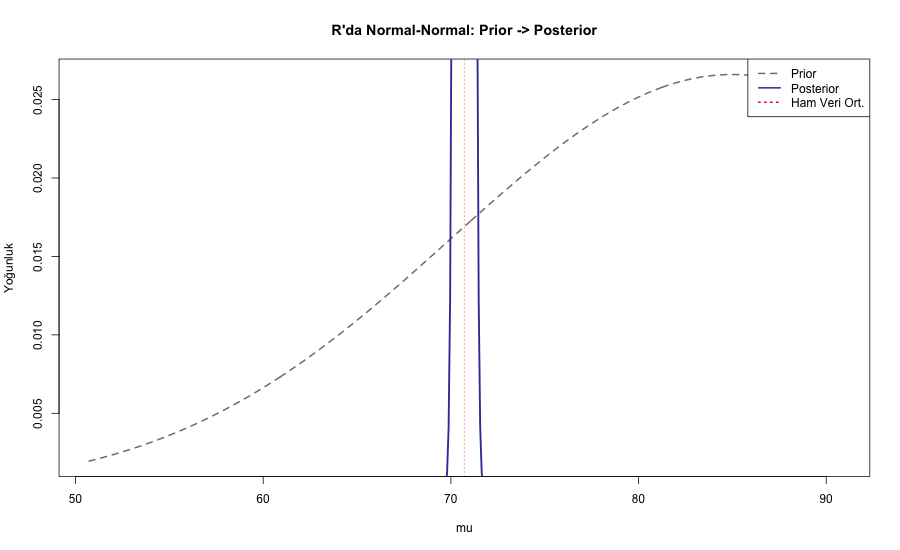

In [16]:
%%R -i credit -w 900 -h 550

amount_r <- credit$Amount
amount_r <- amount_r[amount_r < quantile(amount_r, 0.99)]

sigma_bilinen <- sd(amount_r)
n_obs <- length(amount_r)
x_bar <- mean(amount_r)

mu0 <- 85; tau0 <- 15

tau_n2 <- 1 / (1/tau0^2 + n_obs/sigma_bilinen^2)
mu_n <- tau_n2 * (mu0/tau0^2 + n_obs*x_bar/sigma_bilinen^2)

cat("Posterior: N(", round(mu_n, 3), ",", round(tau_n2, 4), ")\n")
cat("Posterior standart sapması:", round(sqrt(tau_n2), 4), "\n")

x_vals <- seq(mu_n - 20, mu_n + 20, length.out = 500)
plot(x_vals, dnorm(x_vals, mu0, tau0), type = "l", lty = 2, col = "gray50", lwd = 2,
     main = "R'da Normal-Normal: Prior -> Posterior", xlab = "mu", ylab = "Yoğunluk")
lines(x_vals, dnorm(x_vals, mu_n, sqrt(tau_n2)), col = "#4a3aa7", lwd = 2.5)
abline(v = x_bar, col = "red", lty = 3)
legend("topright", legend = c("Prior", "Posterior", "Ham Veri Ort."), col = c("gray50", "#4a3aa7", "red"), lty = c(2,1,3), lwd = 2)

---
# 🗄️ SQL Uygulaması (DuckDB)

Eşlenik prior güncellemesinin SQL tarafı hep aynı kalıba oturuyor: `COUNT`, `SUM` ile
gerekli istatistikleri (n, S/k gibi) çekip, posterior parametrelerini basit aritmetikle hesaplamak.

In [17]:
import duckdb
con = duckdb.connect()
con.register('ab_tbl', ab_clean)
con.register('cookie_tbl', cookie)
print('DuckDB hazır ✓')

DuckDB hazır ✓


---
### 🅰️🅱️ SQL 1 — Beta-Binomial Posterior Parametreleri

**Ne yapıyoruz?**  
Python 1'deki bilgili prior'u ($\alpha=2, \beta=20$) SQL sorgusunun içine sabit olarak
gömüp, doğrudan posterior parametrelerini hesaplıyoruz.

In [18]:
sql_beta_post = con.execute("""
    SELECT
        "group",
        COUNT(*) AS n,
        SUM(converted) AS basari,
        2 + SUM(converted) AS alpha_posterior,
        20 + (COUNT(*) - SUM(converted)) AS beta_posterior
    FROM ab_tbl
    WHERE "group" = 'treatment'
    GROUP BY "group"
""").df()

print(sql_beta_post.to_string(index=False))
print("\nBu satır, Python 1'deki alpha_post/beta_post değerleriyle birebir aynı çıkmalı.")

    group      n  basari  alpha_posterior  beta_posterior
treatment 143397 17025.0          17027.0        126392.0

Bu satır, Python 1'deki alpha_post/beta_post değerleriyle birebir aynı çıkmalı.


---
### 🎮 SQL 2 — Gamma-Poisson Posterior Parametreleri

**Ne yapıyoruz?**  
`sum_gamerounds` için toplam olay sayısını ($S$) ve gözlem sayısını ($n$) SQL'de hesaplayıp,
Gamma posterior parametrelerine dönüştürüyoruz.

In [19]:
sql_gamma_post = con.execute("""
    WITH temiz AS (
        SELECT sum_gamerounds
        FROM cookie_tbl
        WHERE sum_gamerounds < (SELECT QUANTILE_CONT(sum_gamerounds, 0.99) FROM cookie_tbl)
    )
    SELECT
        COUNT(*) AS n_oyuncu,
        SUM(sum_gamerounds) AS toplam_tur,
        40 + SUM(sum_gamerounds) AS alpha_posterior,
        1 + COUNT(*) AS beta_posterior,
        ROUND((40 + SUM(sum_gamerounds)) / (1.0 + COUNT(*)), 4) AS posterior_ortalama_lambda
    FROM temiz
""").df()

print(sql_gamma_post.to_string(index=False))
print("\nposterior_ortalama_lambda, Python 2'deki 'posterior_mean' değeriyle örtüşmeli.")

 n_oyuncu  toplam_tur  alpha_posterior  beta_posterior  posterior_ortalama_lambda
    89283   3972030.0        3972070.0           89284                     44.488

posterior_ortalama_lambda, Python 2'deki 'posterior_mean' değeriyle örtüşmeli.


---
### 📊 SQL 3 — Tüm Aileleri Tek Sorguda Karşılaştırma (Grup Bazlı)

**Ne yapıyoruz?**  
Cookie Cats'te hem `gate_30` hem `gate_40` için AYNI ANDA Beta-Binomial (retention_7) posterior
parametrelerini hesaplayıp, iki grubu yan yana karşılaştıran özet bir tablo çıkarıyoruz.

In [20]:
sql_compare = con.execute("""
    SELECT
        version,
        COUNT(*) AS n,
        SUM(CAST(retention_7 AS INT)) AS basari,
        1 + SUM(CAST(retention_7 AS INT)) AS alpha_posterior,
        1 + (COUNT(*) - SUM(CAST(retention_7 AS INT))) AS beta_posterior,
        ROUND(
            (1 + SUM(CAST(retention_7 AS INT))) * 1.0 /
            (1 + SUM(CAST(retention_7 AS INT)) + 1 + (COUNT(*) - SUM(CAST(retention_7 AS INT)))),
            4
        ) AS posterior_beklenen_oran
    FROM cookie_tbl
    GROUP BY version
    ORDER BY version
""").df()

print(sql_compare.to_string(index=False))
print("\nposterior_beklenen_oran = alpha/(alpha+beta) formülüyle Beta dağılımının beklenen değeri.")

version     n  basari  alpha_posterior  beta_posterior  posterior_beklenen_oran
gate_30 44700  8502.0           8503.0         36199.0                   0.1902
gate_40 45489  8279.0           8280.0         37211.0                   0.1820

posterior_beklenen_oran = alpha/(alpha+beta) formülüyle Beta dağılımının beklenen değeri.


---
## ✏️ Egzersizler

### **E1 (Python) - Credit Card Fraud (Normal-Normal)**
`creditcard.csv`'de `Class=1` (fraud) olan işlemlerin `Amount` ortalamasını,
Normal-Normal eşlenikliğiyle tahmin et. Prior olarak `mu0=50, tau0=30` kullan (fraud işlemlerin
tutarı hakkında belirsiz bir önsel inanç). Posterior ortalamasını ham veri ortalamasıyla karşılaştır.

Prior: N(50, 30²)
Veri: n=281958, x̄=70.72, σ(bilinen)=129.04

Posterior: N(70.715, 0.0591)
Posterior standart sapması: 0.2430 (prior'unkinden 30, ÇOK daha dar!)


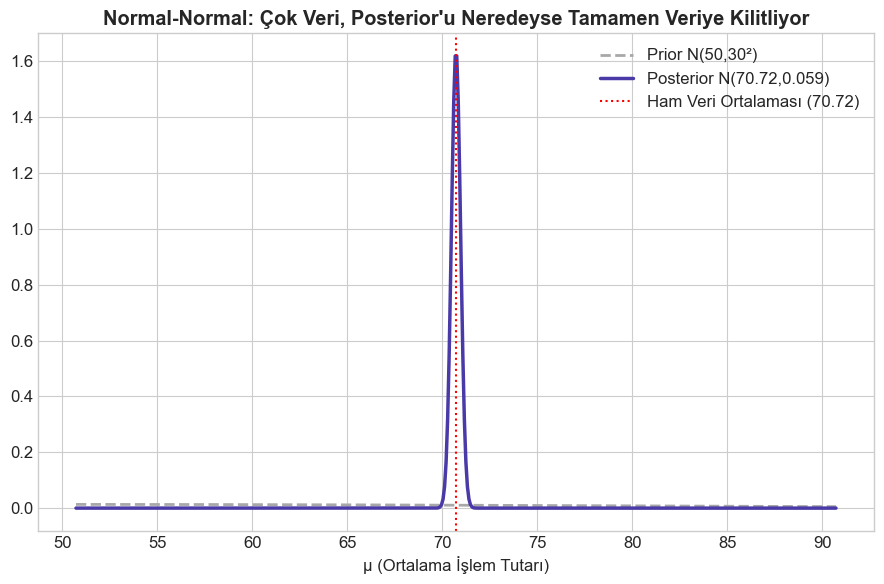

In [32]:
amount = credit['Amount']
amount_clean = amount[amount < amount.quantile(0.99)]  # asiri ucdegerleri kirp
sigma_bilinen = amount_clean.std()  # bilindigini varsaydigimiz populasyon std'si
n_obs = len(amount_clean)
x_bar = amount_clean.mean()

mu0, tau0 = 50, 30 #Belirsiz bir prior: "ortalama muhtemelen 50 dolar civari, +-30 dolar belirsizlikle"

tau_n2 = 1 / (1/tau0**2 + n_obs/sigma_bilinen**2)
mu_n = tau_n2 * (mu0/tau0**2 + n_obs*x_bar/sigma_bilinen**2)

print(f"Prior: N({mu0}, {tau0}²)")
print(f"Veri: n={n_obs}, x̄={x_bar:.2f}, σ(bilinen)={sigma_bilinen:.2f}")
print(f"\nPosterior: N({mu_n:.3f}, {tau_n2:.4f})")
print(f"Posterior standart sapması: {np.sqrt(tau_n2):.4f} (prior'unkinden {tau0}, ÇOK daha dar!)")

x = np.linspace(mu_n - 20, mu_n + 20, 500)
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(x, stats.norm.pdf(x, mu0, tau0), '--', color='#a8a8a8', linewidth=2, label=f'Prior N({mu0},{tau0}²)')
ax.plot(x, stats.norm.pdf(x, mu_n, np.sqrt(tau_n2)), color='#4a3aa7', linewidth=2.5,
        label=f'Posterior N({mu_n:.2f},{tau_n2:.3f})')
ax.axvline(x_bar, color='red', linestyle=':', label=f'Ham Veri Ortalaması ({x_bar:.2f})')
ax.set_title('Normal-Normal: Çok Veri, Posterior\'u Neredeyse Tamamen Veriye Kilitliyor', fontweight='bold')
ax.set_xlabel('μ (Ortalama İşlem Tutarı)')
ax.legend()
plt.tight_layout()
plt.show()

### **E2 (Python + SQL) - A/B Testi (Beta-Binomial)** 

`ab_data.csv`'de `control` grubu için Beta-Binomial posterior'unu **hem
SQL'de hem Python'da** ayrı ayrı hesapla (prior olarak `Beta(3,17)` kullan — "dönüşüm oranı
muhtemelen düşük" varsayımı). İki sonucun birebir örtüştüğünü doğrula.

In [34]:
sql_beta_post = con.execute("""
    SELECT
        "group",
        COUNT(*) AS n,
        SUM(converted) AS basari,
        3 + SUM(converted) AS alpha_posterior,
        17 + (COUNT(*) - SUM(converted)) AS beta_posterior
    FROM ab_tbl
    WHERE "group" = 'control'
    GROUP BY "group"
""").df()

print(sql_beta_post.to_string(index=False))

control = ab_clean[ab_clean['group'] == 'control']
c_success, c_total = control['converted'].sum(), len(control)

alpha_prior, beta_prior = 3, 17

print(f"Control grubu: n={c_total}, başarı={c_success}")
print(f"Prior: Beta({alpha_prior},{beta_prior})")
alpha_post = alpha_prior + c_success
beta_post = beta_prior + (c_total - c_success)
print(f"Posterior: Beta({alpha_post},{beta_post})")

  group      n  basari  alpha_posterior  beta_posterior
control 143293 17220.0          17223.0        126090.0
Control grubu: n=143293, başarı=17220
Prior: Beta(3,17)
Posterior: Beta(17223,126090)


---
### **E3 (Python) Cookie Cats (Gamma-Poisson)**
`cookie_cats.csv`'de `sum_gamerounds` için Gamma-Poisson posterior'unu
üç dilde de hesapla, ama bu sefer SADECE `gate_30` grubunu kullan (`version='gate_30'` filtresiyle).
Prior olarak `Gamma(35, 1)` kullan. 

In [37]:
version = 'gate_30'

cookie = pd.read_csv('data/cookie_cats.csv')
round_gate_30 = cookie[cookie['version'] == version]['sum_gamerounds']
rounds_clean = round_gate_30[round_gate_30 < round_gate_30.quantile(0.99)]

print(f"Gate_30 versiyonu: n={len(rounds_clean)}, Ortalama tur sayısı: {rounds_clean.mean():.2f}")

alpha_prior_g, beta_prior_g = 35, 1 # Belirsiz bir prior: "ortalama oyuncu ~35 tur oynuyor, +-1 tur belirsizlikle"

n_oyuncu = len(rounds_clean)
toplam_tur = rounds_clean.sum()

alpha_post_g = alpha_prior_g + toplam_tur
beta_post_g = beta_prior_g + n_oyuncu

posterior_mean = alpha_post_g / beta_post_g
print(f"\nGamma-Poisson Posterior: Gamma({alpha_post_g:.0f}, {beta_post_g})")
print(f"Posterior ortalama oran tahmini (λ): {posterior_mean:.3f}")
print(f"(Karşılaştırma - ham veri ortalaması: {rounds_clean.mean():.3f})")

Gate_30 versiyonu: n=44249, Ortalama tur sayısı: 44.61

Gamma-Poisson Posterior: Gamma(1974064, 44250)
Posterior ortalama oran tahmini (λ): 44.612
(Karşılaştırma - ham veri ortalaması: 44.612)


---
### **E4 (R) MCMC (Dirichlet-Multinomial)** 
Dirichlet-Multinomial'i R'da uygula: `MCMCpack` paketindeki `rdirichlet()` fonksiyonunu
kullanarak (veya paket yoksa `gtools::rdirichlet()`), Python 4'teki 3-kategorili örneği R'da
tekrarla. Posterior'dan 10.000 örnek çekip her kategorinin "en olası lider" olma olasılığını hesapla.

In [44]:
%%R -w 900 -h 550

library(MCMCpack)
categories <- c('1-2 Yıldız (Kötü)', '3 Yıldız (Orta)', '4-5 Yıldız (İyi)')

prior_alpha <- c(2, 2, 2)
prior_beta <- c(2, 2, 2)

rng <- set.seed(5)
gercek_oranlar <- c(0.15, 0.25, 0.60) # gizli "gercek" oranlar (simulasyon icin)
n_yorum <- 200
gozlem <- rmultinom(1, n_yorum, gercek_oranlar)

posterior_alpha <- prior_alpha + gozlem

cat("Gözlemlenen yorum sayıları:", paste(gozlem, collapse = ", "), "\n")
cat("Prior Dirichlet(", paste(prior_alpha, collapse = ", "), ")\n")
cat("Posterior Dirichlet(", paste(posterior_alpha, collapse = ", "), ")\n")

prior_beklenen <- prior_alpha / sum(prior_alpha)
posterior_beklenen <- posterior_alpha / sum(posterior_alpha)

samples <- rdirichlet(10000, posterior_alpha)
en_yuksek_kategori <- apply(samples, 1, which.max)
for (i in 1:length(categories)) {
    cat(sprintf("P(%s en yüksek oranlı kategori) = %.4f\n", categories[i], mean(en_yuksek_kategori == i)))
}

Gözlemlenen yorum sayıları: 29, 65, 106 
Prior Dirichlet( 2, 2, 2 )
Posterior Dirichlet( 31, 67, 108 )
P(1-2 Yıldız (Kötü) en yüksek oranlı kategori) = 0.0000
P(3 Yıldız (Orta) en yüksek oranlı kategori) = 0.0006
P(4-5 Yıldız (İyi) en yüksek oranlı kategori) = 0.9994


---
## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| [Prob4DS — Stanley Chan](https://probability4datascience.com) | Ch. 9.5 | Conjugate priors |
| [Harvard STAT 110](https://youtube.com/playlist?list=PL2SOU6wwxB0uwwH80KTQ6ht66KWxbzTIo) | Ders 6 | Bayes güncellemeleri, eşlenik dağılımlar |
| [Conjugate Prior Cheat Sheet (Duke Univ.)](https://www.cs.ubc.ca/~murphyk/Papers/bayesGauss.pdf) | — | Formüllerin toplu referansı (Kevin Murphy notları) |
| [Seeing Theory](https://seeing-theory.brown.edu/bayesian-inference) | Bayesian Inference | İnteraktif — Beta-Binomial güncelleme simülasyonu |
| [Kaggle — Mobile Games A/B Testing (Cookie Cats)](https://www.kaggle.com/datasets/mursideyarkin/mobile-games-ab-testing-cookie-cats) | Veri | cookie_cats.csv kaynağı |
| [Kaggle — A/B Testing Dataset](https://www.kaggle.com/datasets/zhangluyuan/ab-testing) | Veri | ab_data.csv kaynağı |
| [Kaggle — Credit Card Fraud](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) | Veri | creditcard.csv kaynağı |